In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("/content/retail_data_synthetic_50k.xlsx")
#df_orig = df.copy()
df.head()

,Transaction_ID,Customer_ID,Gender,Age,Category,Quantity,Unit_Price,Discount,Date,Store_Region,Online_Or_Offline,Payment_Method,Total_Amount
0,TXN-00000,CUST-1127,Female,60,Furniture,9,202.12,0.26,2023-02-12,North,Online,Digital Wallet,1346.12
1,TXN-00001,CUST-1460,Male,30,Beauty,4,75.03,0.05,2021-12-04,West,Online,Digital Wallet,285.11
2,TXN-00002,CUST-0861,Male,52,Clothing,1,374.66,0.15,2020-10-21,South,Online,Cash,318.46
3,TXN-00003,CUST-1295,Non-binary,38,Electronics,7,71.98,0.30,2020-04-26,East,Online,Credit Card,352.70
4,TXN-00004,CUST-1131,Male,47,Grocery,2,169.25,0.02,2022-06-03,West,Online,Cash,331.73


In [3]:
print("Shape:", df.shape)

Shape: (50000, 13)


In [4]:
df.describe()

,Age,Quantity,Unit_Price,Discount,Date,Total_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000.000000
mean,43.425100,4.986980,252.122316,0.200063,2021-12-28 15:02:42.432000256,1004.289097
min,18.000000,1.000000,5.010000,0.000000,2020-01-01 00:00:00,3.480000
25%,30.000000,3.000000,127.837500,0.100000,2020-12-27 00:00:00,321.007500
50%,43.000000,5.000000,252.350000,0.200000,2021-12-28 00:00:00,765.855000
75%,56.000000,7.000000,375.662500,0.300000,2022-12-31 00:00:00,1488.305000
max,69.000000,9.000000,499.990000,0.400000,2023-12-31 00:00:00,4477.140000
std,15.009896,2.577119,143.094619,0.115804,NaN,845.558082


In [5]:
df.columns = [c.strip().replace(' ', '_').lower() for c in df.columns]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_id     50000 non-null  object        
 1   customer_id        50000 non-null  object        
 2   gender             50000 non-null  object        
 3   age                50000 non-null  int64         
 4   category           50000 non-null  object        
 5   quantity           50000 non-null  int64         
 6   unit_price         50000 non-null  float64       
 7   discount           50000 non-null  float64       
 8   date               50000 non-null  datetime64[ns]
 9   store_region       50000 non-null  object        
 10  online_or_offline  50000 non-null  object        
 11  payment_method     50000 non-null  object        
 12  total_amount       50000 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory 

In [6]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
#df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.day_name()

In [7]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", cat_cols)
for c in cat_cols:
    print(c, "-> unique:", df[c].nunique())

Categorical columns: ['transaction_id', 'customer_id', 'gender', 'category', 'store_region', 'online_or_offline', 'payment_method', 'day_of_week']
transaction_id -> unique: 50000
customer_id -> unique: 1999
gender -> unique: 3
category -> unique: 5
store_region -> unique: 4
online_or_offline -> unique: 2
payment_method -> unique: 3
day_of_week -> unique: 7


In [8]:
df = df.drop(columns = ['date', 'transaction_id', 'customer_id'], axis = 1)

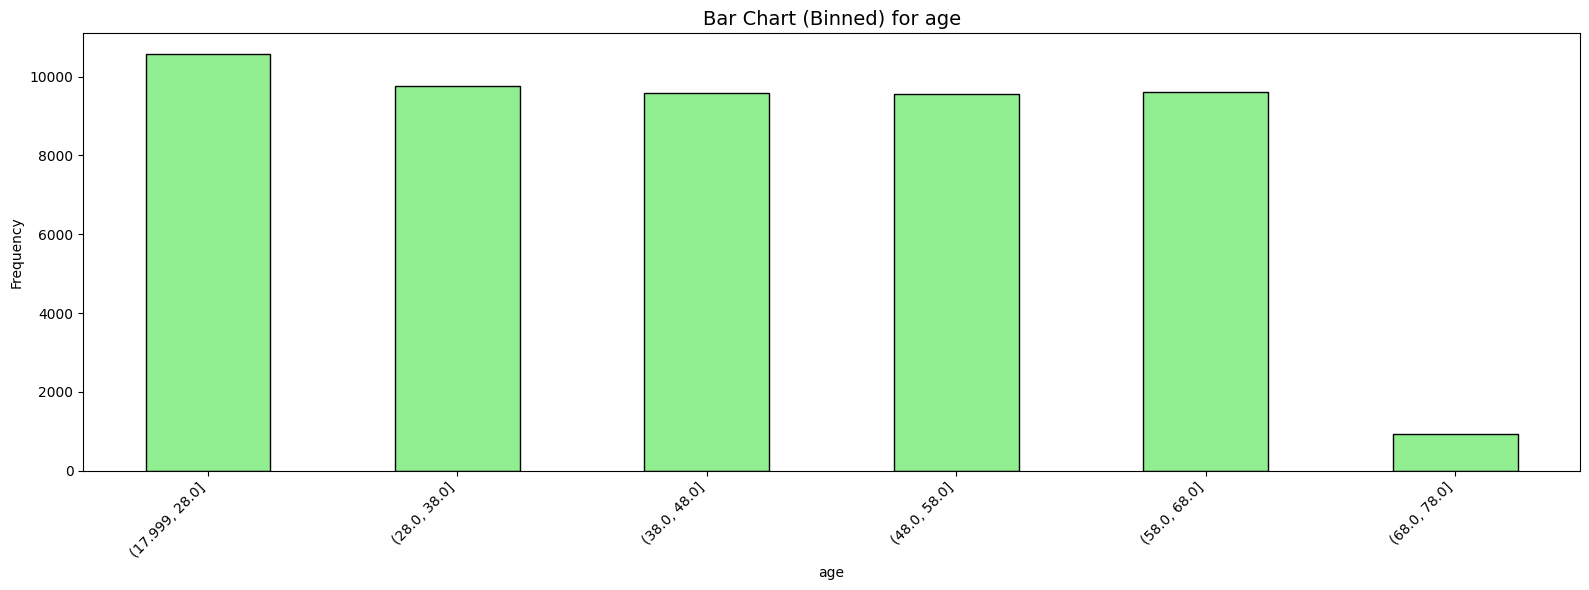

In [9]:
categorical_cols = ['gender', 'category', 'store_region', 'online_or_offline','payment_method','year','month','day_of_week']
numerical_cols = ['age']

plt.figure(figsize=(16, 6 * len(numerical_cols)))

# Chart for each numeric column
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols), 1, i)

    # Bining numeric values
    bin_width = 10
    bins = np.arange(df[col].min(), df[col].max() + bin_width, bin_width)
    df[col].value_counts(bins=bins).sort_index().plot(kind='bar', color='lightgreen', edgecolor='black')

    plt.title(f"Bar Chart (Binned) for {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

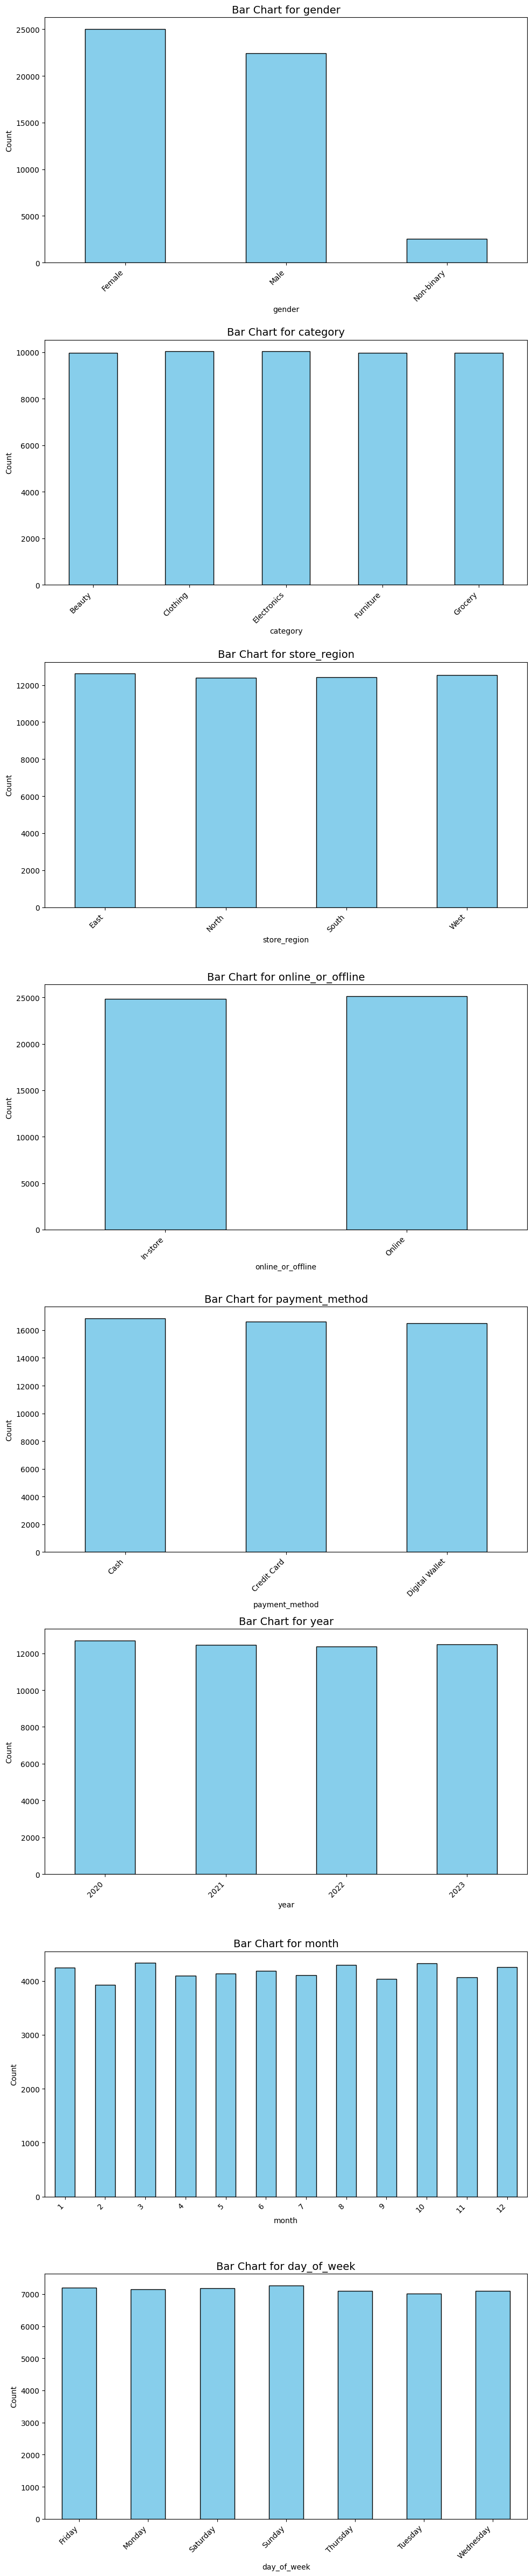

In [10]:
plt.figure(figsize=(10, 6 * len(categorical_cols)))

# Bar chart for each categorical column
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(len(categorical_cols), 1, i)
    df[col].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f"Bar Chart for {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [11]:
X = df.drop(columns=['total_amount'], axis = 1)
y = df['total_amount']

In [12]:
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [13]:
categorical_transformer = Pipeline(steps = [("encoder", OneHotEncoder(handle_unknown='ignore'))])
numeric_transformer = Pipeline(steps = [("scaler", StandardScaler())])

preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
models = {
    "LinearRegression": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "XGBRegressor": XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42, verbosity=0),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
predictions = {}

In [19]:
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    predictions[name] = y_pred
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append([name, r2, mae, mse, rmse])

In [20]:
results_df = pd.DataFrame(results, columns=['Model','R²','MAE','MSE','RMSE'])
print("\nModel Performance Summary:\n", results_df.sort_values(by='R²', ascending=False))


Model Performance Summary:
               Model        R²         MAE            MSE        RMSE
2     Random Forest  0.999875    5.868758      89.389412    9.454597
3      XGBRegressor  0.999819    7.989741     129.162506   11.364968
1     Decision Tree  0.999267   14.692924     522.168027   22.850996
4  GradientBoosting  0.998397   25.969342    1141.953583   33.792804
0  LinearRegression  0.859560  232.258172  100041.108424  316.292757



 LinearRegression Visualizations


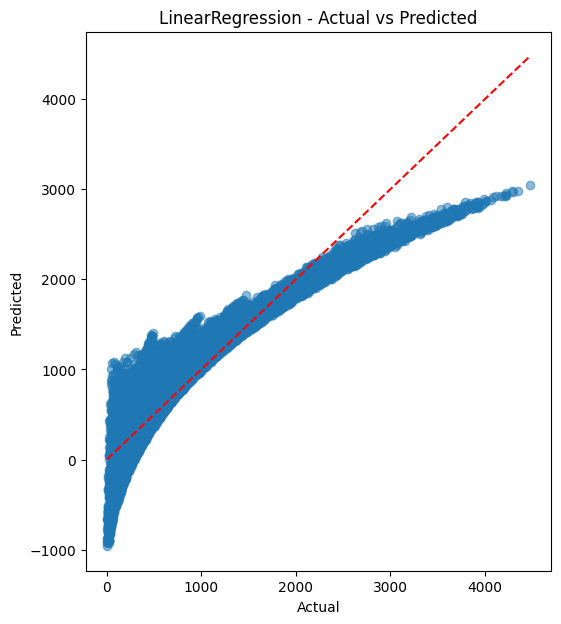

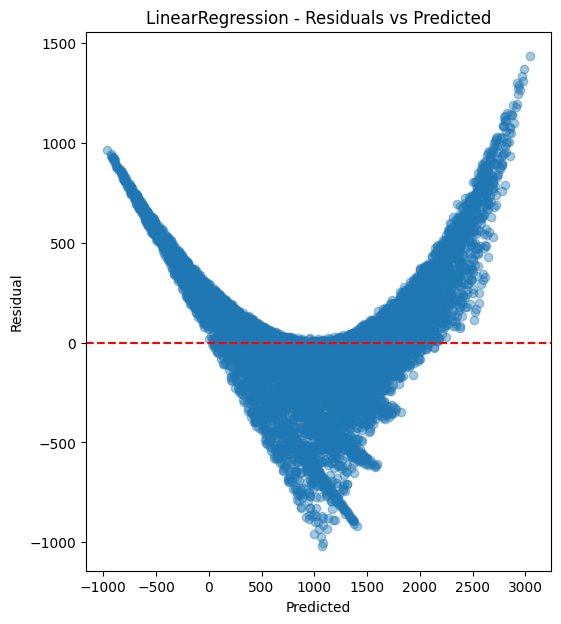

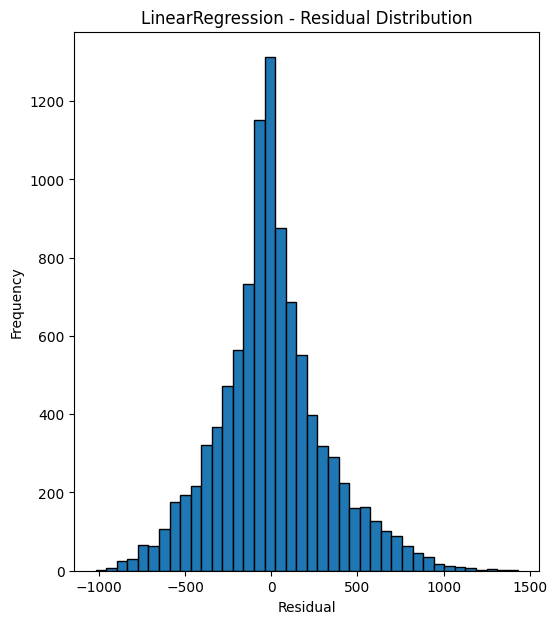


 Decision Tree Visualizations


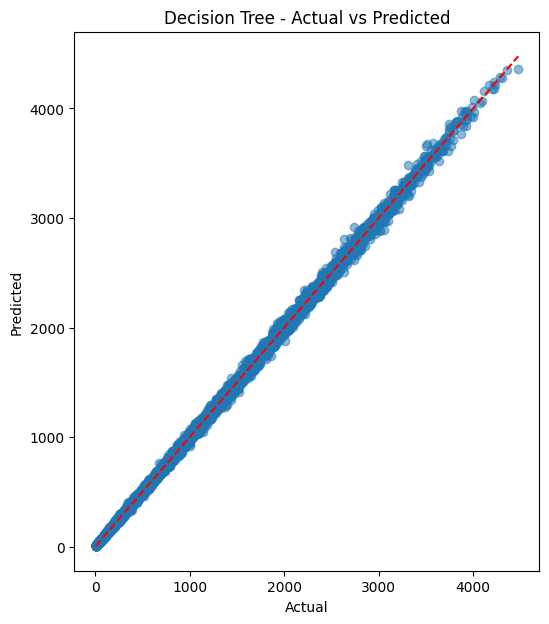

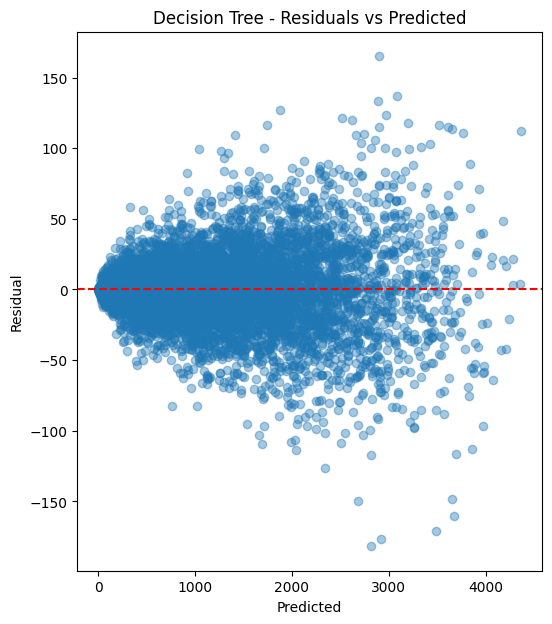

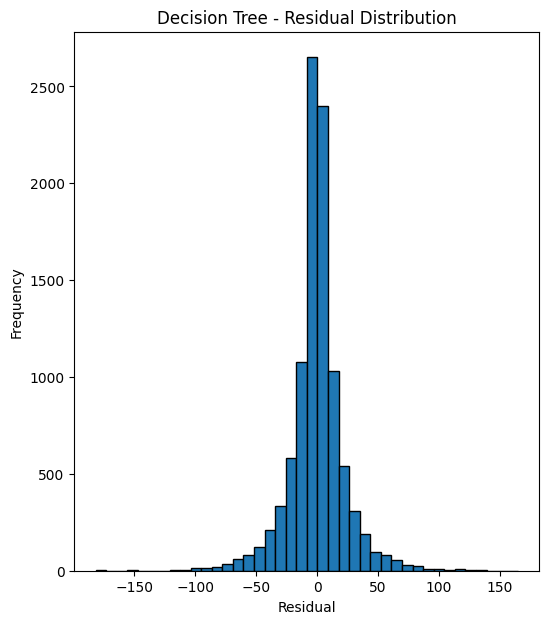

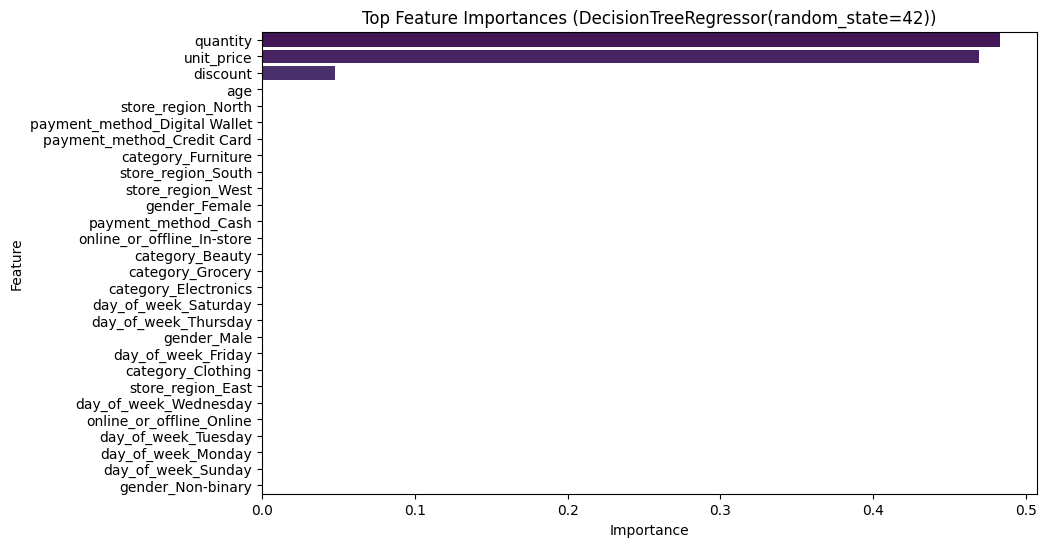


 Random Forest Visualizations


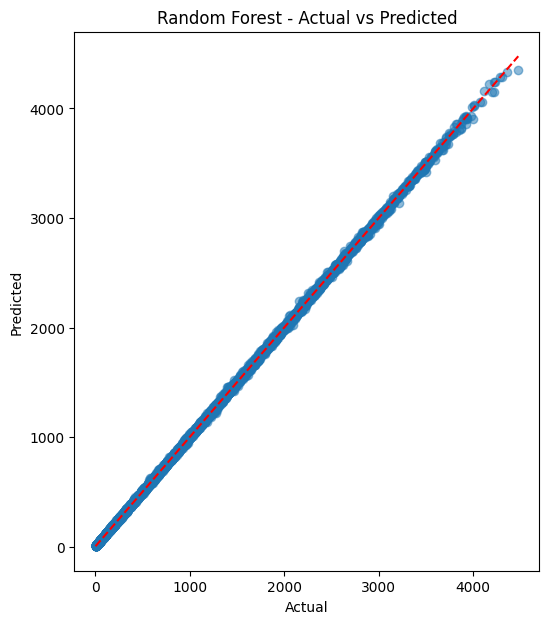

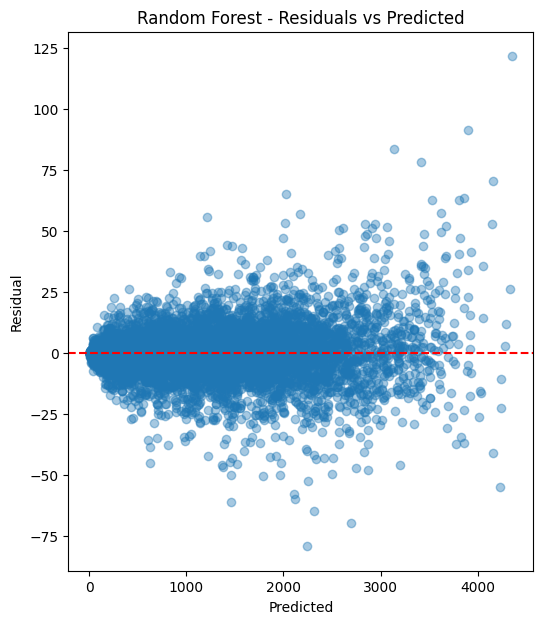

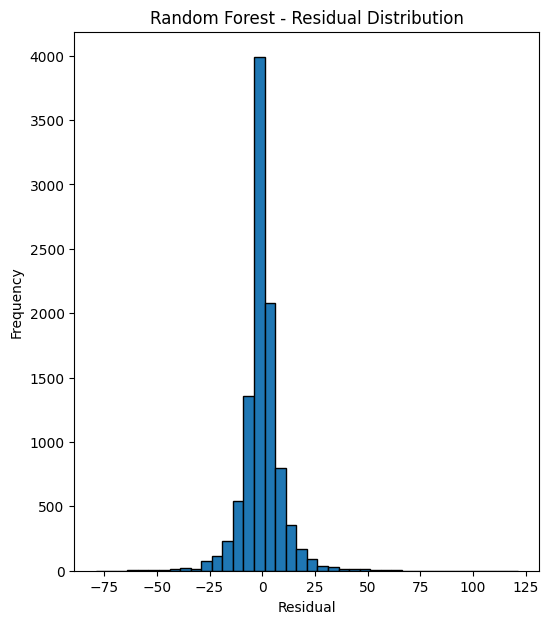

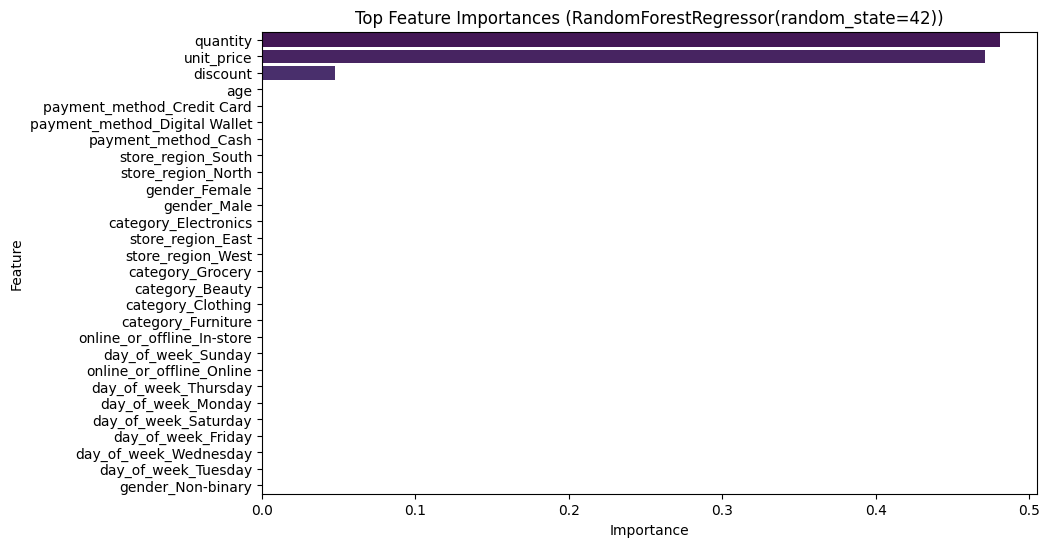


 XGBRegressor Visualizations


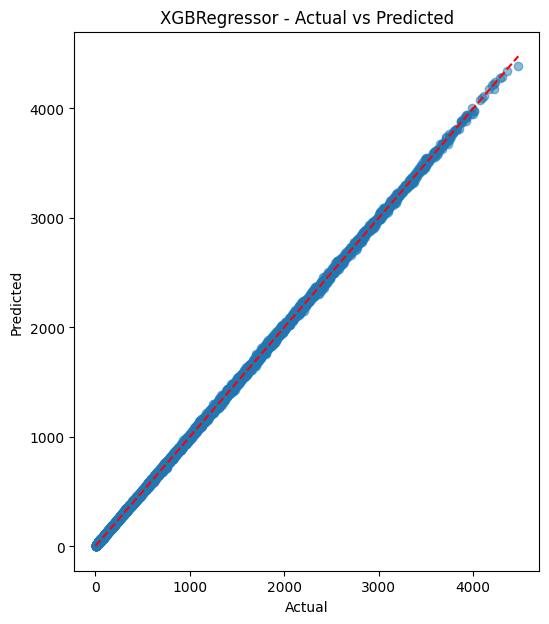

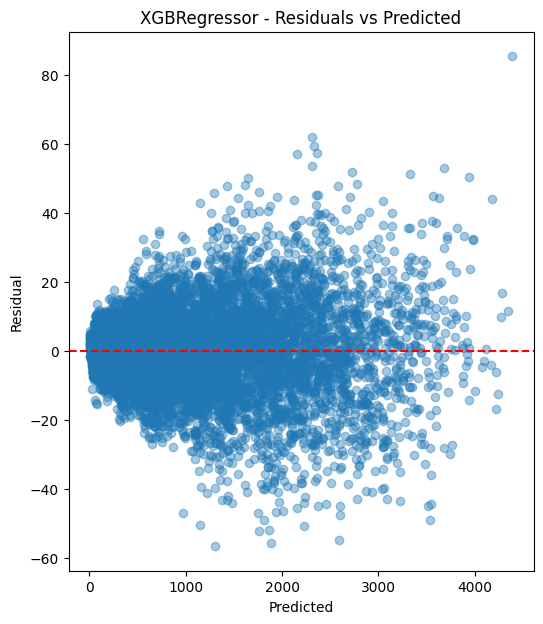

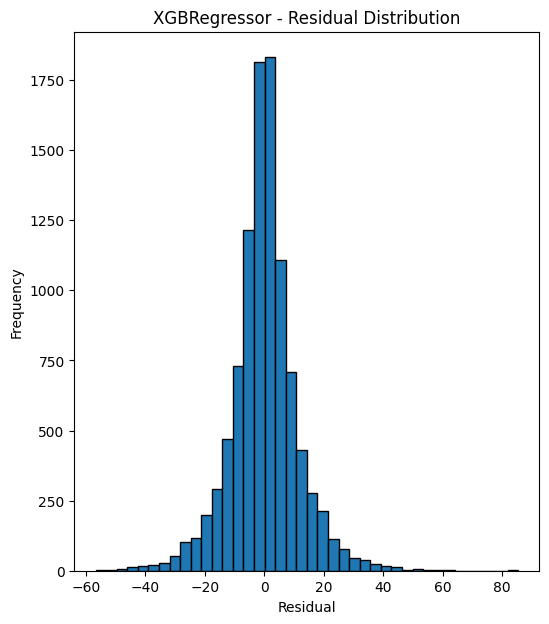

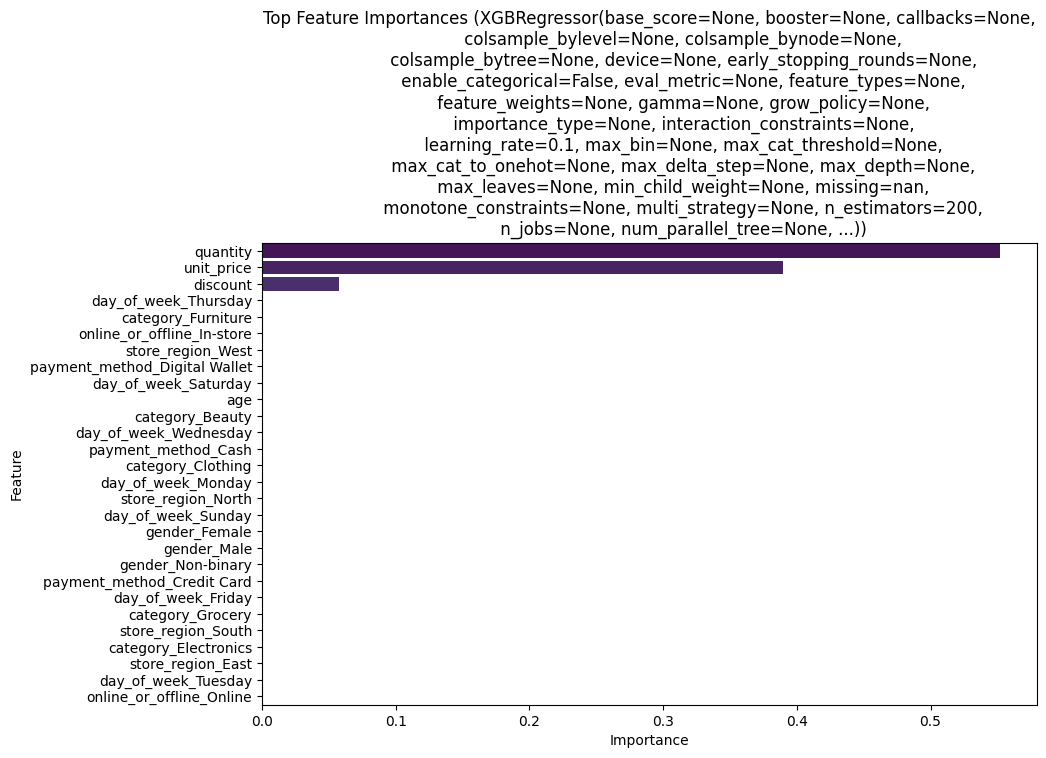


 GradientBoosting Visualizations


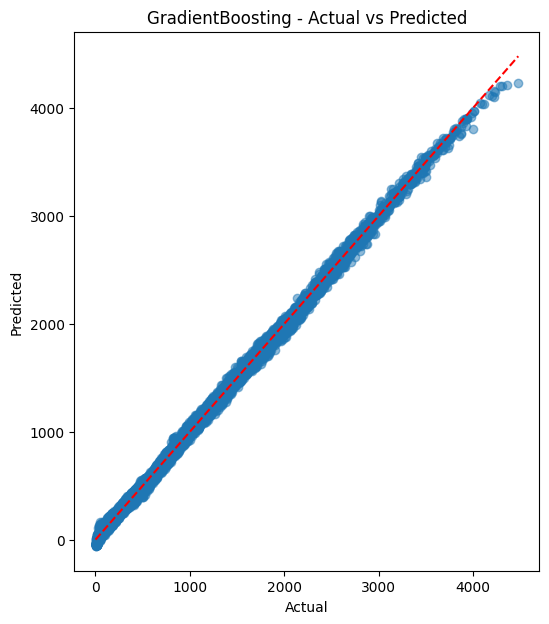

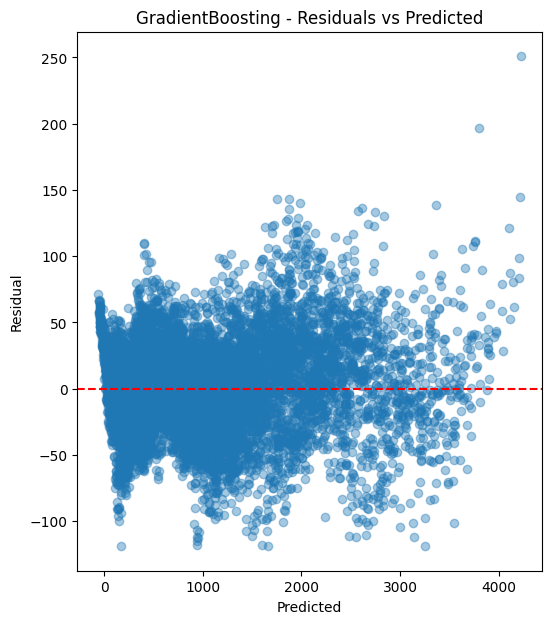

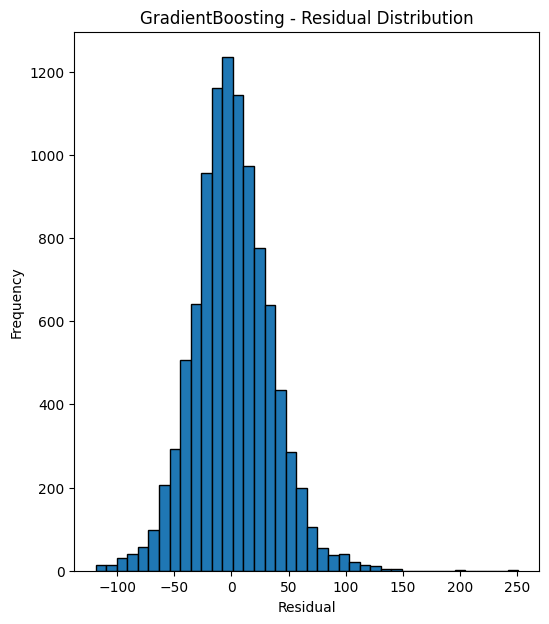

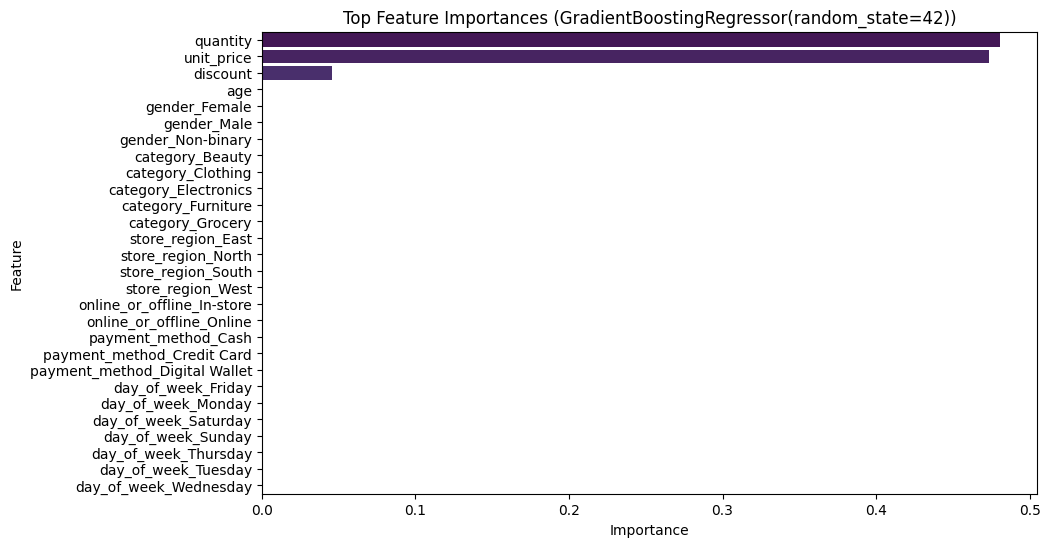

In [23]:
# Visualization
def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(6, 7))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "r--")
    plt.title(title + " - Actual vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(6, 7))
    plt.scatter(y_pred, residuals, alpha=0.4)
    plt.axhline(0, color="r", linestyle="--")
    plt.title(title + " - Residuals vs Predicted")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.show()

    plt.figure(figsize=(6, 7))
    plt.hist(residuals, bins=40, edgecolor="black")
    plt.title(title + " - Residual Distribution")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.show()

def plot_feature_importance(model, name, features, top_n=20):
    if hasattr(model, "feature_importances_"):
      ohe = preprocessor.named_transformers_['cat']
      cat_names = ohe.get_feature_names_out(categorical_features)
      feature_names = np.concatenate([numeric_features, cat_names])
      importances = model.feature_importances_
      fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
      fi_df = fi_df.sort_values(by='Importance', ascending=False)

      plt.figure(figsize=(10,6))
      sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
      plt.title(f"Top Feature Importances ({model})")
      plt.show()

for name, model in models.items():
    print(f"\n {name} Visualizations")
    y_pred = predictions[name]
    plot_actual_vs_pred(y_test, y_pred, name)
    plot_residuals(y_test, y_pred, name)
    if hasattr(model, "feature_importances_"):
        plot_feature_importance(model, name, X.columns)